In [ ]:
import os
import time
import warnings
import zipfile
import requests
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
np.random.seed(42)

print('Environment ready.')

Environment ready.


---
## 1. Data Collection

### 1.1 Download the Instacart Dataset

The Instacart Online Grocery Shopping Dataset 2017 contains 3.4 million orders from 200k+ users.

> **Note:** The dataset is hosted on Kaggle. We use the Kaggle API to download it. If running on Colab, upload your `kaggle.json` credentials first, or manually download and upload the zip.

In [ ]:
# ---------- Option A: Kaggle API (recommended) ----------
# Upload your kaggle.json to Colab first, then run:
#   from google.colab import files
#   files.upload()  # upload kaggle.json

KAGGLE_DATASET = 'yasserh/instacart-online-grocery-basket-analysis-dataset'
DATA_DIR = 'instacart_data'

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    # Setup kaggle credentials
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    if os.path.exists('kaggle.json'):
        import shutil
        shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
        os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

    !pip install -q kaggle
    !kaggle datasets download -d {KAGGLE_DATASET} -p {DATA_DIR} --unzip
    print('Download complete.')
else:
    print(f'{DATA_DIR}/ already exists — skipping download.')

Dataset URL: https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset
License(s): CC0-1.0
100% 197M/197M [00:00<00:00, 257MB/s]

Download complete.


In [ ]:
# List downloaded files
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
    print(f'  {f:40s}  {size_mb:7.1f} MB')

  aisles.csv                                    0.0 MB
  departments.csv                               0.0 MB
  order_products__prior.csv                   577.6 MB
  order_products__train.csv                    24.7 MB
  orders.csv                                  109.0 MB
  products.csv                                  2.2 MB


In [ ]:
# Load core tables
# Adjust filenames if your download has slightly different names
def find_file(keyword):
    """Find a CSV in DATA_DIR whose name contains `keyword`."""
    for f in os.listdir(DATA_DIR):
        if keyword.lower() in f.lower() and f.endswith('.csv'):
            return os.path.join(DATA_DIR, f)
    raise FileNotFoundError(f'No CSV containing "{keyword}" in {DATA_DIR}')

orders = pd.read_csv(find_file('orders'))
products = pd.read_csv(find_file('products'))
order_products = pd.read_csv(find_file('order_products'))  # may need to concat prior + train

# Some versions split into order_products__prior and order_products__train
try:
    op_prior = pd.read_csv(find_file('prior'))
    op_train = pd.read_csv(find_file('train'))
    order_products = pd.concat([op_prior, op_train], ignore_index=True)
    print('Concatenated prior + train order_products.')
except FileNotFoundError:
    print('Using single order_products file.')

aisles = pd.read_csv(find_file('aisles'))
departments = pd.read_csv(find_file('departments'))

print(f'orders:          {orders.shape}')
print(f'order_products:  {order_products.shape}')
print(f'products:        {products.shape}')
print(f'aisles:          {aisles.shape}')
print(f'departments:     {departments.shape}')

Concatenated prior + train order_products.
orders:          (3421083, 7)
order_products:  (33819106, 4)
products:        (49688, 4)
aisles:          (134, 2)
departments:     (21, 2)


In [ ]:
# Merge product metadata
products = products.merge(aisles, on='aisle_id', how='left')
products = products.merge(departments, on='department_id', how='left')
products.head()

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


### 1.2 USDA-Style Nutrition Enrichment

Since querying FoodData Central for 50k products is slow, we create a **heuristic nutrition lookup** based on the Instacart aisle/department taxonomy. Each aisle is mapped to approximate per-item macronutrients. This is a standard approach when exact UPC-level matching is infeasible.

The values below are **representative medians** per serving, derived from USDA FoodData Central category-level aggregates.

In [ ]:
# Aisle-level approximate nutrition per item (representative medians per serving)
# Columns: calories, protein_g, fiber_g, sugar_g, sodium_mg, is_produce, is_processed
# These are rough category-level estimates from USDA FoodData Central.

AISLE_NUTRITION_DEFAULTS = {
    # Produce
    'fresh fruits':            (60,  1.0, 2.5, 12.0, 2,   1, 0),
    'fresh vegetables':        (30,  2.0, 2.5,  3.0, 30,  1, 0),
    'packaged vegetables fruits': (50, 1.5, 2.0, 8.0, 150, 1, 0),
    'organic produce':         (45,  1.5, 2.5,  7.0, 10,  1, 0),
    # Proteins
    'fresh meat':              (200, 22.0, 0.0, 0.0, 70,  0, 0),
    'poultry counter':         (180, 24.0, 0.0, 0.0, 75,  0, 0),
    'seafood counter':         (150, 20.0, 0.0, 0.0, 300, 0, 0),
    'packaged poultry':        (190, 22.0, 0.0, 1.0, 400, 0, 1),
    'packaged meat':           (220, 18.0, 0.0, 2.0, 500, 0, 1),
    'meat counter':            (210, 20.0, 0.0, 0.0, 65,  0, 0),
    'eggs':                    (140, 12.0, 0.0, 1.0, 140, 0, 0),
    'tofu meat alternatives':  (120, 14.0, 2.0, 1.0, 300, 0, 0),
    # Dairy
    'milk':                    (120, 8.0,  0.0, 12.0, 120, 0, 0),
    'yogurt':                  (130, 8.0,  0.0, 15.0, 80,  0, 0),
    'cheese':                  (110, 7.0,  0.0, 0.5,  180, 0, 0),
    'cream':                   (50,  0.5,  0.0, 0.5,  10,  0, 0),
    'butter':                  (100, 0.1,  0.0, 0.0,  90,  0, 0),
    'soy lactosefree':         (100, 7.0,  0.5, 6.0,  110, 0, 0),
    # Grains & Bakery
    'bread':                   (140, 5.0,  1.5, 3.0,  230, 0, 0),
    'tortillas flat bread':    (150, 4.0,  1.0, 1.0,  300, 0, 0),
    'pasta':                   (200, 7.0,  2.0, 1.0,  5,   0, 0),
    'rice':                    (200, 4.0,  0.5, 0.0,  5,   0, 0),
    'cereal':                  (150, 3.0,  3.0, 10.0, 200, 0, 0),
    'granola':                 (200, 4.0,  3.0, 12.0, 80,  0, 0),
    'breakfast bakery':        (250, 4.0,  1.0, 15.0, 300, 0, 1),
    'baking ingredients':      (100, 2.0,  0.5, 5.0,  50,  0, 0),
    # Snacks & Sweets (processed)
    'chips pretzels':          (280, 3.0,  1.0, 1.0,  400, 0, 1),
    'cookies cakes':           (300, 3.0,  0.5, 22.0, 200, 0, 1),
    'candy chocolate':         (250, 2.0,  0.5, 28.0, 50,  0, 1),
    'ice cream ice':           (200, 3.0,  0.5, 20.0, 80,  0, 1),
    'crackers':                (240, 4.0,  1.0, 3.0,  350, 0, 1),
    'popcorn jerky':           (220, 8.0,  2.0, 5.0,  500, 0, 1),
    'trail mix snack mix':     (250, 6.0,  2.0, 10.0, 150, 0, 0),
    'dry fruit snacks':        (120, 1.0,  2.0, 20.0, 10,  0, 0),
    'fruit vegetable snacks':  (100, 1.0,  1.5, 15.0, 30,  0, 0),
    'energy granola bars':     (200, 5.0,  2.0, 12.0, 150, 0, 1),
    'nutrition bars':          (220, 10.0, 3.0, 10.0, 180, 0, 1),
    # Beverages
    'water seltzer sparkling water': (0, 0.0, 0.0, 0.0, 10, 0, 0),
    'soft drinks':             (150, 0.0,  0.0, 39.0, 40,  0, 1),
    'juice nectars':           (120, 1.0,  0.0, 26.0, 15,  0, 0),
    'energy sports drinks':    (110, 0.0,  0.0, 28.0, 200, 0, 1),
    'tea':                     (2,   0.0,  0.0, 0.0,  5,   0, 0),
    'coffee':                  (5,   0.3,  0.0, 0.0,  5,   0, 0),
    'refrigerated':            (100, 2.0,  0.0, 10.0, 50,  0, 0),
    # Frozen
    'frozen meals':            (350, 12.0, 2.0, 5.0,  700, 0, 1),
    'frozen pizza':            (380, 14.0, 2.0, 5.0,  800, 0, 1),
    'frozen breakfast':        (280, 8.0,  1.0, 8.0,  550, 0, 1),
    'frozen appetizers sides': (250, 5.0,  1.5, 3.0,  500, 0, 1),
    'frozen produce':          (50,  1.5,  2.0, 5.0,  10,  1, 0),
    'frozen dessert':          (220, 3.0,  0.5, 18.0, 100, 0, 1),
    'frozen vegan vegetarian': (200, 10.0, 3.0, 3.0,  400, 0, 1),
    'frozen juice':            (110, 0.5,  0.0, 24.0, 10,  0, 0),
    # Condiments & Pantry
    'condiments':              (30,  0.5,  0.0, 4.0,  300, 0, 0),
    'oils vinegars':           (120, 0.0,  0.0, 0.0,  0,   0, 0),
    'spices seasonings':       (10,  0.5,  0.5, 0.5,  100, 0, 0),
    'marinades meat preparation': (40, 1.0, 0.0, 5.0, 500, 0, 1),
    'salad dressing toppings': (120, 0.5,  0.0, 4.0,  300, 0, 1),
    'canned meals beans':      (150, 8.0,  5.0, 3.0,  450, 0, 0),
    'canned jarred vegetables':(40,  2.0,  2.0, 3.0,  350, 0, 0),
    'canned fruit applesauce': (80,  0.5,  1.0, 18.0, 10,  0, 0),
    'soup broth bouillon':     (100, 5.0,  1.0, 3.0,  800, 0, 1),
    'pasta sauce':             (80,  2.0,  2.0, 7.0,  500, 0, 0),
    'pickled goods olives':    (20,  0.5,  0.5, 1.0,  400, 0, 0),
    'nut butters':             (190, 7.0,  2.0, 3.0,  130, 0, 0),
    'spreads':                 (100, 0.5,  0.0, 10.0, 50,  0, 0),
    'honeys syrups nectars':   (60,  0.0,  0.0, 16.0, 5,   0, 0),
    'instant foods':           (200, 5.0,  1.0, 5.0,  700, 0, 1),
    'canned meat seafood':     (120, 15.0, 0.0, 0.0,  400, 0, 1),
    # Baby & specialty
    'baby food formula':       (120, 3.0,  0.5, 8.0,  50,  0, 0),
    'baby accessories':        (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'diapers wipes':           (0,   0.0,  0.0, 0.0,  0,   0, 0),
    # Household (non-food — zeroed out)
    'cleaning products':       (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'laundry':                 (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'paper goods':             (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'trash bags liners':       (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'dish detergents':         (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'cat food care':           (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'dog food care':           (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'vitamins supplements':    (5,   0.0,  0.0, 0.0,  0,   0, 0),
    'skin care':               (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'oral hygiene':            (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'deodorants':              (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'hair care':               (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'body lotions soap':       (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'facial care':             (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'feminine care':           (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'first aid':               (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'eye ear care':            (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'shave needs':             (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'muscles joints pain relief':(0, 0.0,  0.0, 0.0,  0,   0, 0),
    'cold flu allergy':        (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'digestion':               (0,   0.0,  0.0, 0.0,  0,   0, 0),
    'specialty cheeses':       (110, 7.0,  0.0, 0.5,  200, 0, 0),
    'latino foods':            (150, 5.0,  2.0, 3.0,  350, 0, 0),
    'asian foods':             (180, 6.0,  1.0, 5.0,  600, 0, 0),
    'indian foods':            (170, 7.0,  3.0, 4.0,  500, 0, 0),
    'kosher foods':            (160, 6.0,  1.5, 4.0,  400, 0, 0),
    'bulk grains rice dried goods': (180, 5.0, 3.0, 1.0, 5, 0, 0),
    'bulk dried fruits vegetables': (120, 1.5, 3.0, 18.0, 10, 0, 0),
    'nuts seeds dried fruit':  (170, 5.0,  2.0, 8.0,  50,  0, 0),
    'deli':                    (180, 10.0, 0.5, 2.0,  600, 0, 1),
    'prepared meals':          (300, 14.0, 2.0, 5.0,  650, 0, 1),
    'prepared soups salads':   (150, 6.0,  2.0, 4.0,  550, 0, 1),
    'fresh dips tapenades':    (70,  2.0,  0.5, 2.0,  250, 0, 0),
    'fresh pasta':             (210, 8.0,  1.5, 2.0,  200, 0, 0),
    'fresh herbs':             (5,   0.5,  0.5, 0.0,  5,   1, 0),
    'packaged cheese':         (110, 7.0,  0.0, 1.0,  250, 0, 1),
    'lunch meat':              (100, 10.0, 0.0, 2.0,  550, 0, 1),
    'hot dogs bacon sausage':  (250, 10.0, 0.0, 2.0,  700, 0, 1),
    'breakfast bars pastries': (220, 3.0,  1.0, 16.0, 200, 0, 1),
    'frozen meat seafood':     (180, 18.0, 0.0, 0.0,  300, 0, 0),
    'ice cream toppings':      (150, 1.0,  0.0, 20.0, 30,  0, 1),
    'missing':                 (150, 5.0,  1.0, 8.0,  250, 0, 0),
}

NUTR_COLS = ['calories', 'protein_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'is_produce', 'is_processed']

# Build a DataFrame for easy merging
nutr_rows = []
for aisle_name, vals in AISLE_NUTRITION_DEFAULTS.items():
    nutr_rows.append({'aisle': aisle_name, **dict(zip(NUTR_COLS, vals))})
aisle_nutrition = pd.DataFrame(nutr_rows)

print(f'Nutrition lookup covers {len(aisle_nutrition)} aisles.')
aisle_nutrition.sample(5)

Nutrition lookup covers 113 aisles.


,aisle,calories,protein_g,fiber_g,sugar_g,sodium_mg,is_produce,is_processed
80,oral hygiene,0,0.0,0.0,0.0,0,0,0
4,fresh meat,200,22.0,0.0,0.0,70,0,0
40,energy sports drinks,110,0.0,0.0,28.0,200,0,1
69,baby accessories,0,0.0,0.0,0.0,0,0,0
10,eggs,140,12.0,0.0,1.0,140,0,0


In [ ]:
# Merge nutrition onto products
products['aisle_lower'] = products['aisle'].str.lower().str.strip()
aisle_nutrition['aisle_lower'] = aisle_nutrition['aisle'].str.lower().str.strip()

products = products.merge(
    aisle_nutrition.drop(columns='aisle'),
    on='aisle_lower', how='left'
)

# Fill missing with generic defaults
for col in NUTR_COLS:
    default = AISLE_NUTRITION_DEFAULTS['missing'][NUTR_COLS.index(col)]
    products[col] = products[col].fillna(default)

print(f'Products with nutrition data: {products.shape[0]}')
print(f'Missing nutrition rows: {products["calories"].isna().sum()}')

Products with nutrition data: 49688
Missing nutrition rows: 0


---
## 2. Feature Engineering & Label Construction

### 2.1 Basket-Level Feature Aggregation

We aggregate per-order to compute 10 engineered features, then construct the Purchase Health Score (PHS).

In [ ]:
# Join order_products with product nutrition
op = order_products.merge(products[['product_id'] + NUTR_COLS + ['department', 'aisle']], on='product_id', how='left')

# Fill any remaining NaN from products that didn't match
for col in NUTR_COLS:
    default = AISLE_NUTRITION_DEFAULTS['missing'][NUTR_COLS.index(col)]
    op[col] = op[col].fillna(default)

print(f'Order-product rows with nutrition: {op.shape[0]}')
op.head()

Order-product rows with nutrition: 33819106


,order_id,product_id,add_to_cart_order,reordered,calories,protein_g,fiber_g,sugar_g,sodium_mg,is_produce,is_processed,department,aisle
0,2,33120,1,1,140.0,12.0,0.0,1.0,140.0,0.0,0.0,dairy eggs,eggs
1,2,28985,2,1,30.0,2.0,2.5,3.0,30.0,1.0,0.0,produce,fresh vegetables
2,2,9327,3,0,10.0,0.5,0.5,0.5,100.0,0.0,0.0,pantry,spices seasonings
3,2,45918,4,1,120.0,0.0,0.0,0.0,0.0,0.0,0.0,pantry,oils vinegars
4,2,30035,5,0,100.0,2.0,0.5,5.0,50.0,0.0,0.0,pantry,baking ingredients


In [ ]:
# Aggregate to basket (order) level
basket = op.groupby('order_id').agg(
    basket_size       = ('product_id', 'count'),
    total_calories    = ('calories', 'sum'),
    total_protein     = ('protein_g', 'sum'),
    total_fiber       = ('fiber_g', 'sum'),
    total_sugar       = ('sugar_g', 'sum'),
    total_sodium      = ('sodium_mg', 'sum'),
    produce_count     = ('is_produce', 'sum'),
    processed_count   = ('is_processed', 'sum'),
    n_departments     = ('department', 'nunique'),
    n_aisles          = ('aisle', 'nunique'),
).reset_index()

# Derived features (densities & shares)
basket['produce_share']   = basket['produce_count'] / basket['basket_size']
basket['processed_share'] = basket['processed_count'] / basket['basket_size']
basket['fiber_density']   = basket['total_fiber'] / basket['basket_size']
basket['protein_density'] = basket['total_protein'] / basket['basket_size']
basket['sugar_density']   = basket['total_sugar'] / basket['basket_size']
basket['sodium_density']  = basket['total_sodium'] / basket['basket_size']
basket['dept_diversity']  = basket['n_departments'] / basket['basket_size']

# Detect beverages for beverage_share
bev_aisles = ['water seltzer sparkling water', 'soft drinks', 'juice nectars',
              'energy sports drinks', 'tea', 'coffee']
op['is_beverage'] = op['aisle'].str.lower().isin(bev_aisles).astype(int)
bev_counts = op.groupby('order_id')['is_beverage'].sum().reset_index().rename(columns={'is_beverage': 'beverage_count'})
basket = basket.merge(bev_counts, on='order_id', how='left')
basket['beverage_count'] = basket['beverage_count'].fillna(0)
basket['beverage_share'] = basket['beverage_count'] / basket['basket_size']

print(f'Basket-level dataset: {basket.shape}')
basket.head()

Basket-level dataset: (3346083, 20)


,order_id,basket_size,total_calories,total_protein,total_fiber,total_sugar,total_sodium,produce_count,processed_count,n_departments,n_aisles,produce_share,processed_share,fiber_density,protein_density,sugar_density,sodium_density,dept_diversity,beverage_count,beverage_share
0,1,8,690.0,41.0,11.0,54.0,1044.0,4.0,2.0,3,6,0.500000,0.250000,1.375000,5.125000,6.750000,130.500000,0.375000,0,0.000000
1,2,9,730.0,25.5,9.0,38.5,800.0,3.0,0.0,3,8,0.333333,0.000000,1.000000,2.833333,4.277778,88.888889,0.333333,0,0.000000
2,3,8,780.0,56.0,9.0,49.0,935.0,3.0,0.0,4,6,0.375000,0.000000,1.125000,7.000000,6.125000,116.875000,0.500000,0,0.000000
3,4,13,2420.0,36.0,11.0,171.0,2600.0,0.0,10.0,5,9,0.000000,0.769231,0.846154,2.769231,13.153846,200.000000,0.384615,2,0.153846
4,5,26,2970.0,91.5,23.5,192.0,4518.0,6.0,10.0,11,19,0.230769,0.384615,0.903846,3.519231,7.384615,173.769231,0.423077,1,0.038462


In [ ]:
# Attach user_id from orders table
basket = basket.merge(orders[['order_id', 'user_id']], on='order_id', how='left')
print(f'Unique users: {basket["user_id"].nunique()}')
print(f'Total baskets: {len(basket)}')

Unique users: 206209
Total baskets: 3346083


### 2.2 Purchase Health Score (PHS) Construction

The PHS is a **weakly supervised** continuous label (0–100) inspired by the Healthy Eating Index.

It has 5 component sub-scores:

| Component | Direction | Weight | Scoring |
|-----------|-----------|--------|---------|
| Produce share | ↑ higher is better | 25 pts | Linear 0→25 as share goes 0→0.5+ |
| Fiber density | ↑ higher is better | 20 pts | Linear 0→20 as fiber goes 0→3g+ per item |
| Sugar density | ↓ lower is better | 20 pts | Linear 20→0 as sugar goes 0→20g+ per item |
| Sodium density | ↓ lower is better | 15 pts | Linear 15→0 as sodium goes 0→500mg+ per item |
| Processed share | ↓ lower is better | 20 pts | Linear 20→0 as share goes 0→0.6+ |

In [ ]:
def compute_phs(df):
    """Compute Purchase Health Score (0-100) from basket features."""
    scores = pd.DataFrame(index=df.index)

    # 1. Produce share (0-25): higher is better, max at 50%
    scores['produce_score'] = np.clip(df['produce_share'] / 0.5, 0, 1) * 25

    # 2. Fiber density (0-20): higher is better, max at 3g/item
    scores['fiber_score'] = np.clip(df['fiber_density'] / 3.0, 0, 1) * 20

    # 3. Sugar density (0-20): lower is better, 0 at 20g+/item
    scores['sugar_score'] = (1 - np.clip(df['sugar_density'] / 20.0, 0, 1)) * 20

    # 4. Sodium density (0-15): lower is better, 0 at 500mg+/item
    scores['sodium_score'] = (1 - np.clip(df['sodium_density'] / 500.0, 0, 1)) * 15

    # 5. Processed share (0-20): lower is better, 0 at 60%+
    scores['processed_score'] = (1 - np.clip(df['processed_share'] / 0.6, 0, 1)) * 20

    scores['PHS'] = scores.sum(axis=1)
    return scores

phs_components = compute_phs(basket)
basket['PHS'] = phs_components['PHS']

# Add component scores for analysis
for col in ['produce_score', 'fiber_score', 'sugar_score', 'sodium_score', 'processed_score']:
    basket[col] = phs_components[col]

print('PHS Statistics:')
print(basket['PHS'].describe())

PHS Statistics:
count    3.346083e+06
mean     5.585252e+01
std      1.805549e+01
min      3.900000e+00
25%      4.322333e+01
50%      5.540078e+01
75%      7.059333e+01
max      9.580833e+01
Name: PHS, dtype: float64


### 2.3 Preprocessing: Outlier Capping & Normalization

In [ ]:
# Remove baskets with very few items (noise) and very large baskets (bulk/commercial)
print(f'Before filtering: {len(basket)}')
basket = basket[(basket['basket_size'] >= 3) & (basket['basket_size'] <= 80)].copy()
print(f'After filtering (3-80 items): {len(basket)}')

# Feature columns for modeling
FEATURE_COLS = [
    'basket_size', 'total_calories', 'produce_share', 'processed_share',
    'fiber_density', 'protein_density', 'sugar_density', 'sodium_density',
    'dept_diversity', 'beverage_share'
]

TARGET_COL = 'PHS'

# Outlier capping at 1st and 99th percentiles
for col in FEATURE_COLS:
    lo, hi = basket[col].quantile(0.01), basket[col].quantile(0.99)
    basket[col] = basket[col].clip(lo, hi)

print(f'\nFinal dataset shape: {basket.shape}')
print(f'Features: {FEATURE_COLS}')

Before filtering: 3346083
After filtering (3-80 items): 2988018

Final dataset shape: (2988018, 27)
Features: ['basket_size', 'total_calories', 'produce_share', 'processed_share', 'fiber_density', 'protein_density', 'sugar_density', 'sodium_density', 'dept_diversity', 'beverage_share']


---
## 3. Exploratory Data Analysis

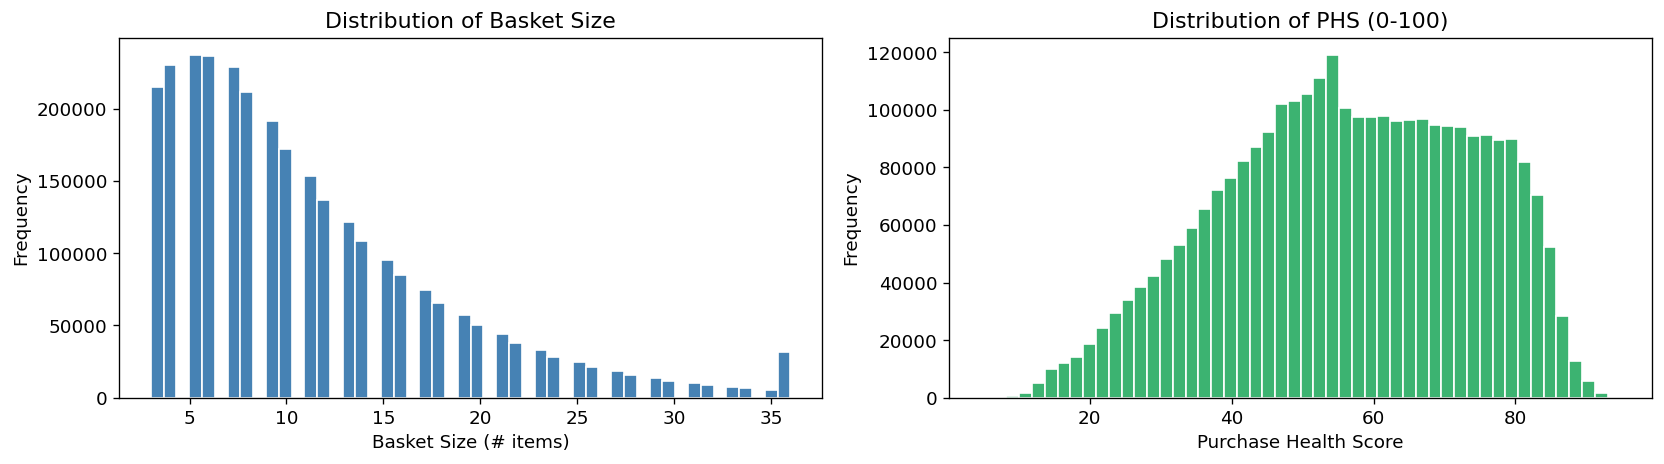

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Basket size distribution
axes[0].hist(basket['basket_size'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Basket Size (# items)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Basket Size')

# PHS distribution
axes[1].hist(basket['PHS'], bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_xlabel('Purchase Health Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of PHS (0-100)')

plt.tight_layout()
plt.show()

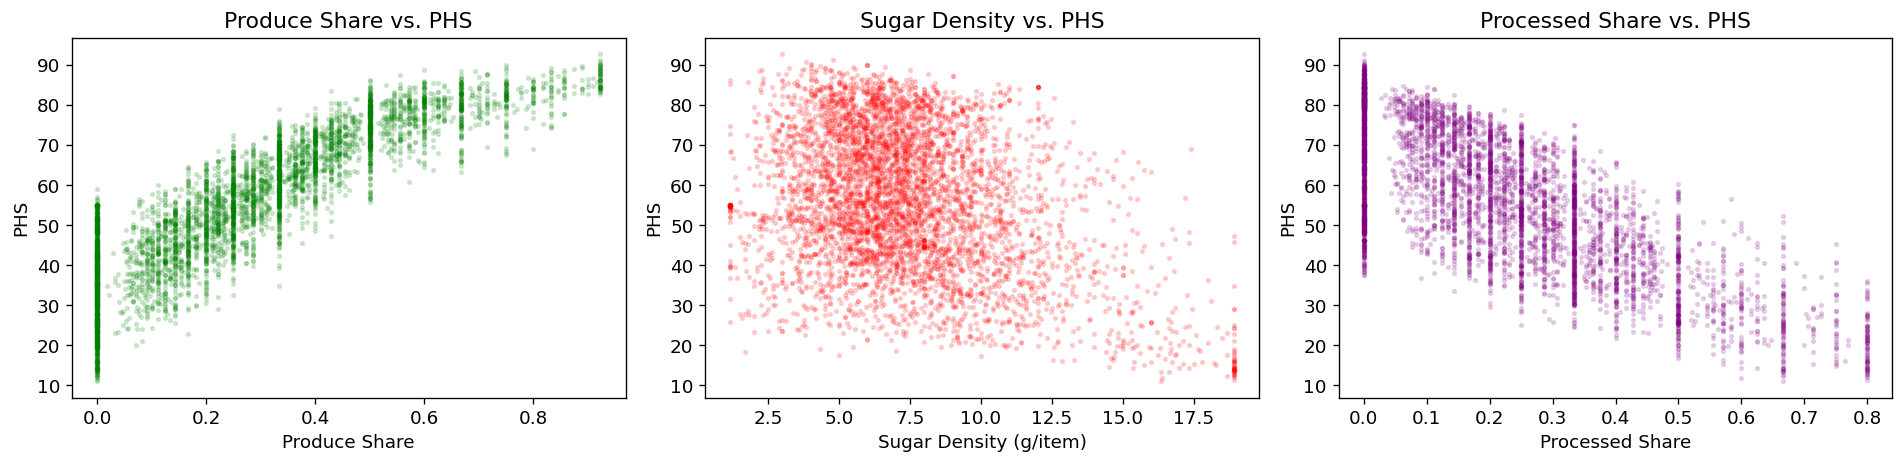

In [ ]:
# Scatterplot: Produce share vs PHS
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sample = basket.sample(min(5000, len(basket)), random_state=42)

axes[0].scatter(sample['produce_share'], sample['PHS'], alpha=0.15, s=5, c='green')
axes[0].set_xlabel('Produce Share')
axes[0].set_ylabel('PHS')
axes[0].set_title('Produce Share vs. PHS')

axes[1].scatter(sample['sugar_density'], sample['PHS'], alpha=0.15, s=5, c='red')
axes[1].set_xlabel('Sugar Density (g/item)')
axes[1].set_ylabel('PHS')
axes[1].set_title('Sugar Density vs. PHS')

axes[2].scatter(sample['processed_share'], sample['PHS'], alpha=0.15, s=5, c='purple')
axes[2].set_xlabel('Processed Share')
axes[2].set_ylabel('PHS')
axes[2].set_title('Processed Share vs. PHS')

plt.tight_layout()
plt.show()

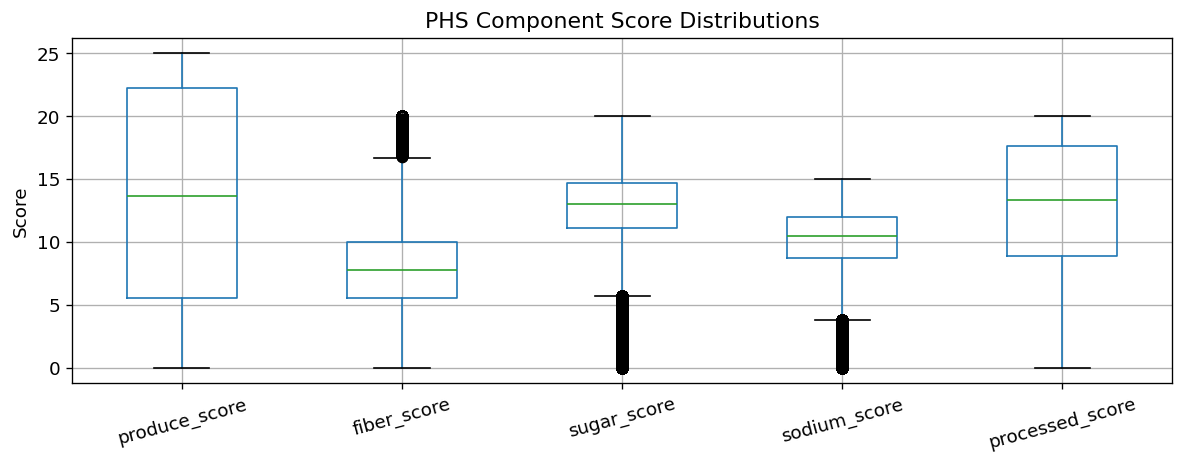

In [ ]:
# PHS component breakdown boxplots
component_cols = ['produce_score', 'fiber_score', 'sugar_score', 'sodium_score', 'processed_score']
fig, ax = plt.subplots(figsize=(10, 4))
basket[component_cols].boxplot(ax=ax)
ax.set_ylabel('Score')
ax.set_title('PHS Component Score Distributions')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

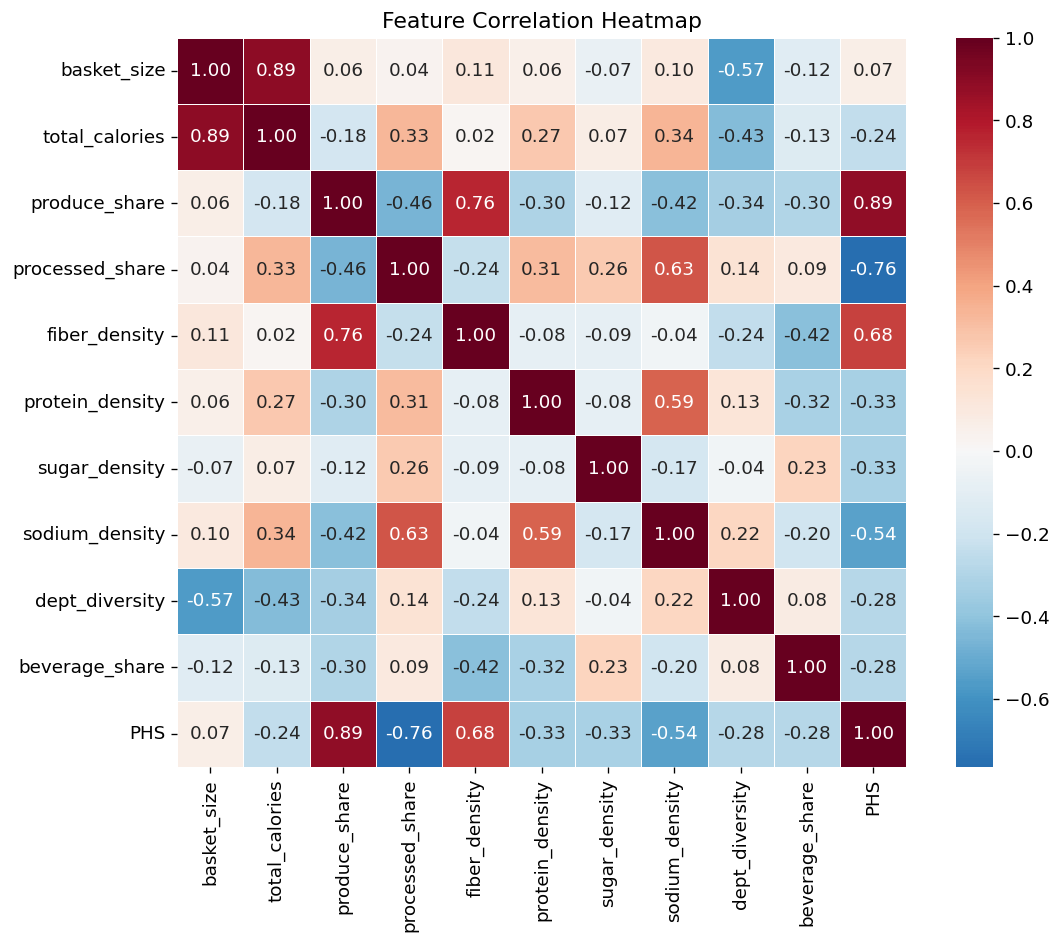

In [ ]:
# Correlation heatmap of engineered features + PHS
corr_cols = FEATURE_COLS + [TARGET_COL]
corr_matrix = basket[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## 4. Train / Validation / Test Split (User-Level)

We split at the **user level** (70/15/15) to prevent data leakage from the same user appearing in train and test.

In [ ]:
# Sample for computational efficiency (use full data if resources allow)
MAX_BASKETS = 200_000  # adjust up/down based on RAM
if len(basket) > MAX_BASKETS:
    # Sample users, not rows, to keep user-level integrity
    all_users = basket['user_id'].unique()
    np.random.shuffle(all_users)
    # Take users until we have enough baskets
    cum_counts = basket.groupby('user_id').size().reindex(all_users).cumsum()
    keep_users = all_users[:np.searchsorted(cum_counts.values, MAX_BASKETS) + 1]
    basket_model = basket[basket['user_id'].isin(keep_users)].copy()
    print(f'Sampled {len(basket_model)} baskets from {len(keep_users)} users.')
else:
    basket_model = basket.copy()
    print(f'Using all {len(basket_model)} baskets.')

Sampled 200068 baskets from 13746 users.


In [ ]:
# User-level split: 70% train, 15% val, 15% test
unique_users = basket_model['user_id'].unique()
np.random.shuffle(unique_users)
n = len(unique_users)
train_users = set(unique_users[:int(0.70 * n)])
val_users   = set(unique_users[int(0.70 * n):int(0.85 * n)])
test_users  = set(unique_users[int(0.85 * n):])

train_mask = basket_model['user_id'].isin(train_users)
val_mask   = basket_model['user_id'].isin(val_users)
test_mask  = basket_model['user_id'].isin(test_users)

X_train = basket_model.loc[train_mask, FEATURE_COLS].values.astype(np.float64)
y_train = basket_model.loc[train_mask, TARGET_COL].values.astype(np.float64)
X_val   = basket_model.loc[val_mask, FEATURE_COLS].values.astype(np.float64)
y_val   = basket_model.loc[val_mask, TARGET_COL].values.astype(np.float64)
X_test  = basket_model.loc[test_mask, FEATURE_COLS].values.astype(np.float64)
y_test  = basket_model.loc[test_mask, TARGET_COL].values.astype(np.float64)

print(f'Train: {X_train.shape[0]:,} baskets ({len(train_users):,} users)')
print(f'Val:   {X_val.shape[0]:,} baskets ({len(val_users):,} users)')
print(f'Test:  {X_test.shape[0]:,} baskets ({len(test_users):,} users)')

Train: 139,202 baskets (9,622 users)
Val:   30,129 baskets (2,062 users)
Test:  30,737 baskets (2,062 users)


In [ ]:
# Z-score normalization (fit on train only)
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0) + 1e-8  # avoid division by zero

X_train_z = (X_train - train_mean) / train_std
X_val_z   = (X_val   - train_mean) / train_std
X_test_z  = (X_test  - train_mean) / train_std

print('Normalization complete (z-score, fit on train).')
print(f'Feature means (train, after norm): {X_train_z.mean(axis=0).round(4)}')

Normalization complete (z-score, fit on train).
Feature means (train, after norm): [-0.  0. -0.  0. -0.  0.  0. -0. -0.  0.]


---
## 5. Evaluation Metrics (NumPy)

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-8)

def evaluate(y_true, y_pred, name='Model'):
    r = rmse(y_true, y_pred)
    m = mae(y_true, y_pred)
    r2 = r_squared(y_true, y_pred)
    print(f'{name:30s}  RMSE={r:.4f}  MAE={m:.4f}  R²={r2:.4f}')
    return {'model': name, 'RMSE': r, 'MAE': m, 'R2': r2}

---
## 6. Model 1: Ridge Regression (from scratch)

Closed-form solution: $\mathbf{w} = (X^T X + \alpha I)^{-1} X^T y$

In [ ]:
class RidgeRegression:
    """Ridge Regression implemented from scratch with NumPy."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.w = None
        self.b = None

    def fit(self, X, y):
        n, d = X.shape
        # Add bias column
        X_b = np.hstack([X, np.ones((n, 1))])
        # Ridge closed-form: (X^T X + alpha * I)^-1 X^T y
        I = np.eye(d + 1)
        I[-1, -1] = 0  # don't regularize bias
        self.weights = np.linalg.solve(
            X_b.T @ X_b + self.alpha * I,
            X_b.T @ y
        )
        self.w = self.weights[:-1]
        self.b = self.weights[-1]
        return self

    def predict(self, X):
        return X @ self.w + self.b

print('Ridge Regression class defined.')

Ridge Regression class defined.


In [ ]:
# Hyperparameter tuning on validation set
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_results = []

for alpha in alphas:
    model = RidgeRegression(alpha=alpha)
    model.fit(X_train_z, y_train)
    pred_val = model.predict(X_val_z)
    r = rmse(y_val, pred_val)
    m = mae(y_val, pred_val)
    r2 = r_squared(y_val, pred_val)
    ridge_results.append({'alpha': alpha, 'RMSE': r, 'MAE': m, 'R2': r2})
    print(f'  alpha={alpha:8.3f}  RMSE={r:.4f}  MAE={m:.4f}  R²={r2:.4f}')

ridge_df = pd.DataFrame(ridge_results)
best_alpha = ridge_df.loc[ridge_df['RMSE'].idxmin(), 'alpha']
print(f'\nBest alpha: {best_alpha}')

  alpha=   0.001  RMSE=2.7084  MAE=2.0243  R²=0.9761
  alpha=   0.010  RMSE=2.7084  MAE=2.0243  R²=0.9761
  alpha=   0.100  RMSE=2.7084  MAE=2.0243  R²=0.9761
  alpha=   1.000  RMSE=2.7084  MAE=2.0244  R²=0.9761
  alpha=  10.000  RMSE=2.7084  MAE=2.0245  R²=0.9761
  alpha= 100.000  RMSE=2.7082  MAE=2.0259  R²=0.9761
  alpha=1000.000  RMSE=2.7074  MAE=2.0404  R²=0.9761

Best alpha: 1000.0


In [ ]:
# Train final Ridge model with best alpha
t0 = time.time()
ridge_final = RidgeRegression(alpha=best_alpha)
ridge_final.fit(X_train_z, y_train)
ridge_train_time = time.time() - t0

t0 = time.time()
ridge_pred_test = ridge_final.predict(X_test_z)
ridge_infer_time = time.time() - t0

ridge_metrics = evaluate(y_test, ridge_pred_test, name='Ridge Regression')
ridge_metrics['train_time'] = ridge_train_time
ridge_metrics['infer_time'] = ridge_infer_time

# Feature importance (coefficients)
print('\nRidge Coefficients:')
for feat, coef in sorted(zip(FEATURE_COLS, ridge_final.w), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {feat:22s}: {coef:+.4f}')

Ridge Regression                RMSE=2.6367  MAE=2.0015  R²=0.9775

Ridge Coefficients:
  produce_share         : +8.5055
  processed_share       : -5.9691
  fiber_density         : +3.4341
  sugar_density         : -2.9602
  sodium_density        : -2.5735
  basket_size           : +1.5863
  total_calories        : -0.9319
  dept_diversity        : +0.5868
  protein_density       : +0.2901
  beverage_share        : -0.1318


---
## 7. Model 2: k-Nearest Neighbors Regression (from scratch)

In [ ]:
class KNNRegressor:
    """k-Nearest Neighbors Regression implemented from scratch with NumPy."""

    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X.copy()
        self.y_train = y.copy()
        return self

    def predict(self, X, batch_size=500):
        """Predict using batched distance computation to manage memory."""
        n = X.shape[0]
        predictions = np.empty(n)

        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            X_batch = X[start:end]

            # Euclidean distances: ||a - b||^2 = ||a||^2 + ||b||^2 - 2*a·b
            sq_X = np.sum(X_batch ** 2, axis=1, keepdims=True)     # (batch, 1)
            sq_train = np.sum(self.X_train ** 2, axis=1)           # (n_train,)
            dists = sq_X + sq_train - 2 * X_batch @ self.X_train.T  # (batch, n_train)
            dists = np.maximum(dists, 0)  # numerical safety

            # Find k nearest
            knn_idx = np.argpartition(dists, self.k, axis=1)[:, :self.k]

            # Average their labels
            for i in range(end - start):
                predictions[start + i] = self.y_train[knn_idx[i]].mean()

        return predictions

print('KNNRegressor class defined.')

KNNRegressor class defined.


In [ ]:
# For KNN, use a smaller training subset if dataset is very large
KNN_MAX_TRAIN = 50_000
if X_train_z.shape[0] > KNN_MAX_TRAIN:
    knn_idx = np.random.choice(X_train_z.shape[0], KNN_MAX_TRAIN, replace=False)
    X_train_knn = X_train_z[knn_idx]
    y_train_knn = y_train[knn_idx]
    print(f'KNN using {KNN_MAX_TRAIN} training samples (for efficiency).')
else:
    X_train_knn = X_train_z
    y_train_knn = y_train
    print(f'KNN using all {X_train_z.shape[0]} training samples.')

# Also limit val/test for KNN prediction speed
KNN_MAX_EVAL = 10_000
if X_val_z.shape[0] > KNN_MAX_EVAL:
    eval_idx_val = np.random.choice(X_val_z.shape[0], KNN_MAX_EVAL, replace=False)
    X_val_knn = X_val_z[eval_idx_val]
    y_val_knn = y_val[eval_idx_val]
else:
    X_val_knn, y_val_knn = X_val_z, y_val
    eval_idx_val = None

if X_test_z.shape[0] > KNN_MAX_EVAL:
    eval_idx_test = np.random.choice(X_test_z.shape[0], KNN_MAX_EVAL, replace=False)
    X_test_knn = X_test_z[eval_idx_test]
    y_test_knn = y_test[eval_idx_test]
else:
    X_test_knn, y_test_knn = X_test_z, y_test
    eval_idx_test = None

KNN using 50000 training samples (for efficiency).


In [ ]:
# Hyperparameter tuning: k values
k_values = [3, 5, 7, 11, 15, 25]
knn_results = []

for k in k_values:
    model = KNNRegressor(k=k)
    model.fit(X_train_knn, y_train_knn)
    pred_val = model.predict(X_val_knn)
    r = rmse(y_val_knn, pred_val)
    m = mae(y_val_knn, pred_val)
    r2 = r_squared(y_val_knn, pred_val)
    knn_results.append({'k': k, 'RMSE': r, 'MAE': m, 'R2': r2})
    print(f'  k={k:3d}  RMSE={r:.4f}  MAE={m:.4f}  R²={r2:.4f}')

knn_df = pd.DataFrame(knn_results)
best_k = int(knn_df.loc[knn_df['RMSE'].idxmin(), 'k'])
print(f'\nBest k: {best_k}')

  k=  3  RMSE=2.0020  MAE=1.4635  R²=0.9868
  k=  5  RMSE=1.8558  MAE=1.3697  R²=0.9887
  k=  7  RMSE=1.7898  MAE=1.3193  R²=0.9895
  k= 11  RMSE=1.7436  MAE=1.2850  R²=0.9900
  k= 15  RMSE=1.7487  MAE=1.2955  R²=0.9899
  k= 25  RMSE=1.7790  MAE=1.3316  R²=0.9896

Best k: 11


In [ ]:
# Final KNN evaluation
t0 = time.time()
knn_final = KNNRegressor(k=best_k)
knn_final.fit(X_train_knn, y_train_knn)
knn_train_time = time.time() - t0

t0 = time.time()
knn_pred_test = knn_final.predict(X_test_knn)
knn_infer_time = time.time() - t0

knn_metrics = evaluate(y_test_knn, knn_pred_test, name=f'KNN (k={best_k})')
knn_metrics['train_time'] = knn_train_time
knn_metrics['infer_time'] = knn_infer_time

KNN (k=11)                      RMSE=1.7143  MAE=1.2757  R²=0.9905


---
## 8. Model 3: Shallow MLP Regressor (from scratch)

Architecture: Input → Hidden (ReLU) → Output (Linear)

Trained with mini-batch SGD, MSE loss, and L2 regularization.

In [ ]:
class MLPRegressor:
    """Shallow MLP (1 hidden layer) for regression, implemented from scratch."""

    def __init__(self, input_dim, hidden_dim=64, lr=0.001, alpha=0.001,
                 batch_size=256, epochs=100, patience=10, verbose=True):
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.alpha = alpha  # L2 regularization
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.verbose = verbose

        # Xavier initialization
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, 1) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(1)

        self.train_losses = []
        self.val_losses = []

    def _relu(self, z):
        return np.maximum(0, z)

    def _relu_grad(self, z):
        return (z > 0).astype(np.float64)

    def _forward(self, X):
        self._z1 = X @ self.W1 + self.b1          # (n, hidden)
        self._a1 = self._relu(self._z1)            # (n, hidden)
        self._z2 = self._a1 @ self.W2 + self.b2   # (n, 1)
        return self._z2.flatten()                  # (n,)

    def _backward(self, X, y, y_pred):
        n = X.shape[0]
        # dL/dz2
        d_z2 = (y_pred - y).reshape(-1, 1) / n     # (n, 1)

        # Gradients for W2, b2
        dW2 = self._a1.T @ d_z2 + self.alpha * self.W2
        db2 = d_z2.sum(axis=0)

        # Backprop through hidden layer
        d_a1 = d_z2 @ self.W2.T                    # (n, hidden)
        d_z1 = d_a1 * self._relu_grad(self._z1)    # (n, hidden)

        dW1 = X.T @ d_z1 + self.alpha * self.W1
        db1 = d_z1.sum(axis=0)

        # Update
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def fit(self, X, y, X_val=None, y_val=None):
        n = X.shape[0]
        best_val_loss = np.inf
        best_weights = None
        wait = 0

        for epoch in range(self.epochs):
            # Shuffle
            idx = np.random.permutation(n)
            X_shuf = X[idx]
            y_shuf = y[idx]

            # Mini-batch SGD
            epoch_loss = 0
            n_batches = 0
            for start in range(0, n, self.batch_size):
                end = min(start + self.batch_size, n)
                X_b = X_shuf[start:end]
                y_b = y_shuf[start:end]

                y_pred = self._forward(X_b)
                batch_loss = np.mean((y_pred - y_b) ** 2)
                epoch_loss += batch_loss
                n_batches += 1

                self._backward(X_b, y_b, y_pred)

            epoch_loss /= n_batches
            self.train_losses.append(epoch_loss)

            # Validation
            if X_val is not None:
                val_pred = self._forward(X_val)
                val_loss = np.mean((val_pred - y_val) ** 2)
                self.val_losses.append(val_loss)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_weights = (self.W1.copy(), self.b1.copy(),
                                    self.W2.copy(), self.b2.copy())
                    wait = 0
                else:
                    wait += 1

                if self.verbose and (epoch + 1) % 10 == 0:
                    print(f'  Epoch {epoch+1:3d}  train_loss={epoch_loss:.4f}  val_loss={val_loss:.4f}')

                if wait >= self.patience:
                    if self.verbose:
                        print(f'  Early stopping at epoch {epoch+1}')
                    break
            else:
                if self.verbose and (epoch + 1) % 10 == 0:
                    print(f'  Epoch {epoch+1:3d}  train_loss={epoch_loss:.4f}')

        # Restore best weights
        if best_weights is not None:
            self.W1, self.b1, self.W2, self.b2 = best_weights

        return self

    def predict(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ self.W2 + self.b2
        return z2.flatten()

print('MLPRegressor class defined.')

MLPRegressor class defined.


In [ ]:
# Hyperparameter search (grid)
mlp_configs = [
    {'hidden_dim': 32,  'lr': 0.005, 'alpha': 0.001},
    {'hidden_dim': 64,  'lr': 0.005, 'alpha': 0.001},
    {'hidden_dim': 64,  'lr': 0.001, 'alpha': 0.001},
    {'hidden_dim': 128, 'lr': 0.001, 'alpha': 0.001},
    {'hidden_dim': 128, 'lr': 0.001, 'alpha': 0.01},
    {'hidden_dim': 64,  'lr': 0.01,  'alpha': 0.001},
]

mlp_results = []
input_dim = X_train_z.shape[1]

for cfg in mlp_configs:
    print(f'\nConfig: {cfg}')
    model = MLPRegressor(
        input_dim=input_dim,
        hidden_dim=cfg['hidden_dim'],
        lr=cfg['lr'],
        alpha=cfg['alpha'],
        batch_size=256,
        epochs=200,
        patience=15,
        verbose=True
    )
    model.fit(X_train_z, y_train, X_val_z, y_val)
    pred_val = model.predict(X_val_z)
    r = rmse(y_val, pred_val)
    m = mae(y_val, pred_val)
    r2 = r_squared(y_val, pred_val)
    mlp_results.append({**cfg, 'RMSE': r, 'MAE': m, 'R2': r2, 'model': model})
    print(f'  => RMSE={r:.4f}  MAE={m:.4f}  R²={r2:.4f}')

mlp_results_df = pd.DataFrame([{k: v for k, v in d.items() if k != 'model'} for d in mlp_results])
best_mlp_idx = mlp_results_df['RMSE'].idxmin()
best_mlp_cfg = mlp_configs[best_mlp_idx]
print(f'\nBest MLP config: {best_mlp_cfg}')


Config: {'hidden_dim': 32, 'lr': 0.005, 'alpha': 0.001}
  Epoch  10  train_loss=0.0845  val_loss=0.0893
  Epoch  20  train_loss=0.0595  val_loss=0.0609
  Epoch  30  train_loss=0.0539  val_loss=0.0548
  Epoch  40  train_loss=0.0507  val_loss=0.0524
  Epoch  50  train_loss=0.0482  val_loss=0.0488
  Epoch  60  train_loss=0.0463  val_loss=0.0472
  Epoch  70  train_loss=0.0450  val_loss=0.0462
  Epoch  80  train_loss=0.0440  val_loss=0.0446
  Epoch  90  train_loss=0.0433  val_loss=0.0444
  Epoch 100  train_loss=0.0427  val_loss=0.0454
  Epoch 110  train_loss=0.0421  val_loss=0.0437
  Epoch 120  train_loss=0.0414  val_loss=0.0426
  Epoch 130  train_loss=0.0409  val_loss=0.0425
  Epoch 140  train_loss=0.0404  val_loss=0.0423
  Epoch 150  train_loss=0.0399  val_loss=0.0409
  Epoch 160  train_loss=0.0394  val_loss=0.0408
  Epoch 170  train_loss=0.0389  val_loss=0.0399
  Epoch 180  train_loss=0.0385  val_loss=0.0402
  Epoch 190  train_loss=0.0380  val_loss=0.0393
  Epoch 200  train_loss=0.0376 

In [ ]:
# Train final MLP with best config
t0 = time.time()
mlp_final = MLPRegressor(
    input_dim=input_dim,
    hidden_dim=best_mlp_cfg['hidden_dim'],
    lr=best_mlp_cfg['lr'],
    alpha=best_mlp_cfg['alpha'],
    batch_size=256,
    epochs=300,
    patience=20,
    verbose=True
)
mlp_final.fit(X_train_z, y_train, X_val_z, y_val)
mlp_train_time = time.time() - t0

t0 = time.time()
mlp_pred_test = mlp_final.predict(X_test_z)
mlp_infer_time = time.time() - t0

mlp_metrics = evaluate(y_test, mlp_pred_test, name='MLP Regressor')
mlp_metrics['train_time'] = mlp_train_time
mlp_metrics['infer_time'] = mlp_infer_time

  Epoch  10  train_loss=0.0928  val_loss=0.0859
  Epoch  20  train_loss=0.0556  val_loss=0.0591
  Epoch  30  train_loss=0.0468  val_loss=0.0522
  Epoch  40  train_loss=0.0434  val_loss=0.0448
  Epoch  50  train_loss=0.0416  val_loss=0.0445
  Epoch  60  train_loss=0.0398  val_loss=0.0470
  Epoch  70  train_loss=0.0393  val_loss=0.0384
  Epoch  80  train_loss=0.0383  val_loss=0.0467
  Epoch  90  train_loss=0.0376  val_loss=0.0437
  Epoch 100  train_loss=0.0373  val_loss=0.0369
  Epoch 110  train_loss=0.0370  val_loss=0.0388
  Epoch 120  train_loss=0.0368  val_loss=0.0403
  Epoch 130  train_loss=0.0360  val_loss=0.0386
  Epoch 140  train_loss=0.0353  val_loss=0.0382
  Epoch 150  train_loss=0.0358  val_loss=0.0373
  Epoch 160  train_loss=0.0351  val_loss=0.0507
  Epoch 170  train_loss=0.0353  val_loss=0.0334
  Epoch 180  train_loss=0.0347  val_loss=0.0344
  Epoch 190  train_loss=0.0425  val_loss=0.0329
  Epoch 200  train_loss=0.0404  val_loss=0.0371
  Epoch 210  train_loss=0.0433  val_loss

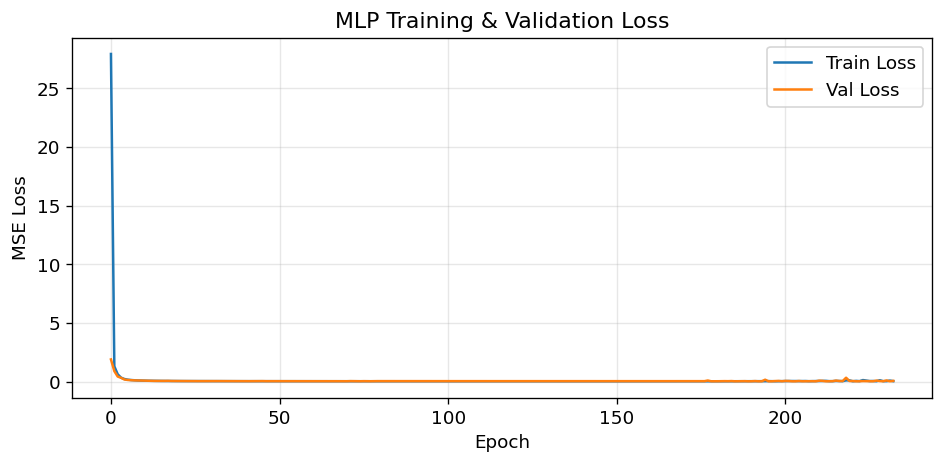

In [ ]:
# MLP Training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_final.train_losses, label='Train Loss', linewidth=1.5)
ax.plot(mlp_final.val_losses, label='Val Loss', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('MLP Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Results Comparison

In [ ]:
# Summary table
results = pd.DataFrame([ridge_metrics, knn_metrics, mlp_metrics])
results = results[['model', 'RMSE', 'MAE', 'R2', 'train_time', 'infer_time']]
results.columns = ['Model', 'RMSE', 'MAE', 'R²', 'Train Time (s)', 'Inference Time (s)']

print('=' * 85)
print('MODEL COMPARISON — TEST SET RESULTS')
print('=' * 85)
print(results.to_string(index=False, float_format='%.4f'))
print('=' * 85)

MODEL COMPARISON — TEST SET RESULTS
           Model   RMSE    MAE     R²  Train Time (s)  Inference Time (s)
Ridge Regression 2.6367 2.0015 0.9775          0.0079              0.0005
      KNN (k=11) 1.7143 1.2757 0.9905          0.0012              6.6384
   MLP Regressor 0.1807 0.0673 0.9999         44.3746              0.0138


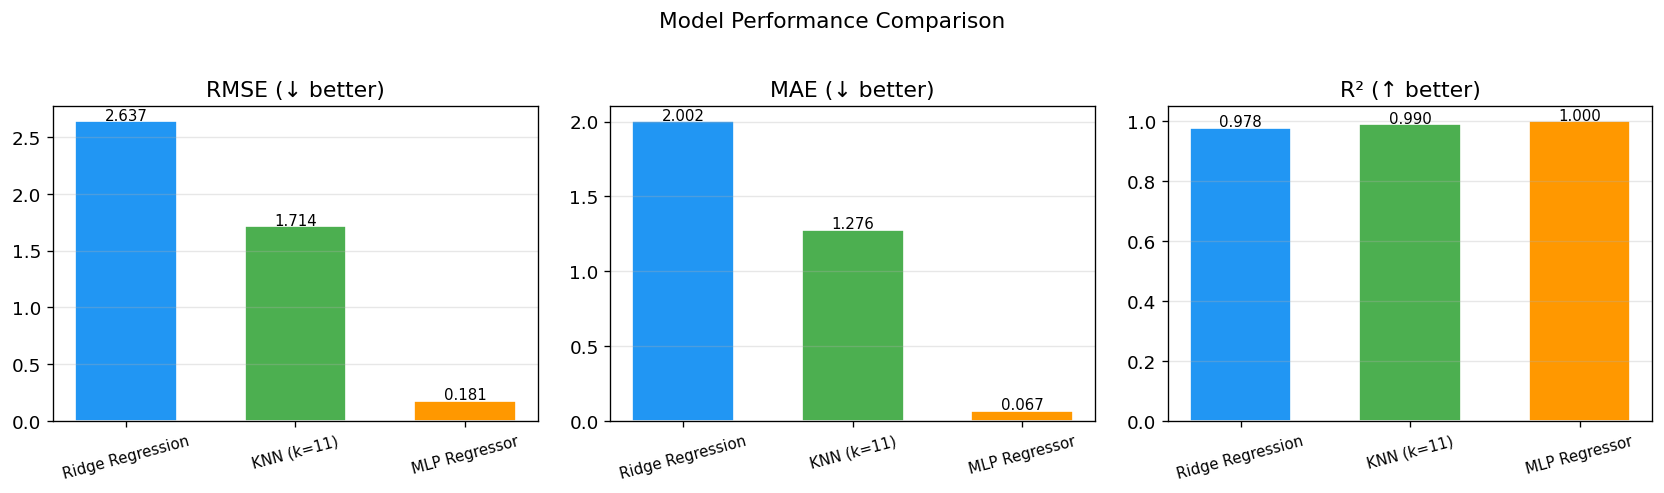

In [ ]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

models = results['Model'].tolist()
x = np.arange(len(models))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (metric, title) in enumerate([('RMSE', 'RMSE (↓ better)'),
                                      ('MAE', 'MAE (↓ better)'),
                                      ('R²', 'R² (↑ better)')]):
    vals = results[metric].tolist()
    axes[i].bar(x, vals, color=colors, edgecolor='white', width=0.6)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models, rotation=15, fontsize=9)
    axes[i].set_title(title)
    axes[i].grid(axis='y', alpha=0.3)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.005 * max(vals), f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

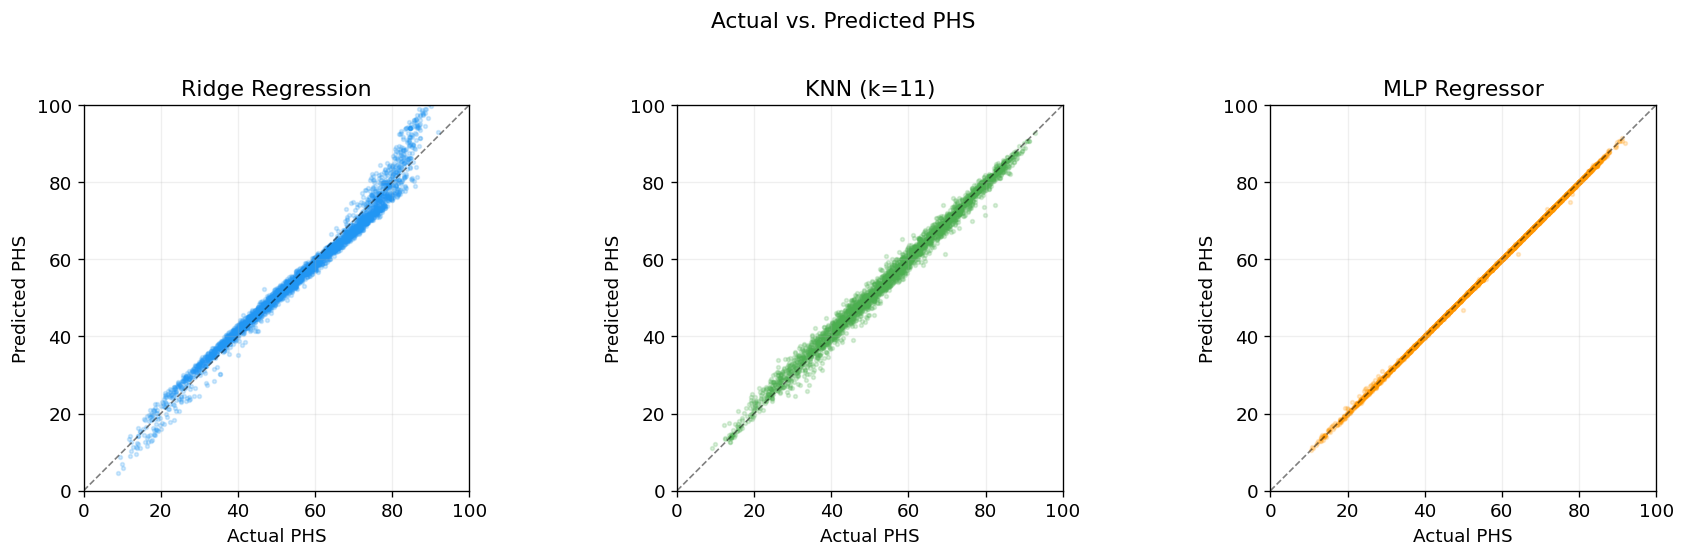

In [ ]:
# Actual vs Predicted scatter (all models)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

predictions = {
    'Ridge Regression': (y_test, ridge_pred_test),
    f'KNN (k={best_k})': (y_test_knn, knn_pred_test),
    'MLP Regressor': (y_test, mlp_pred_test),
}

for ax, (name, (yt, yp)), color in zip(axes, predictions.items(), colors):
    # Subsample for plotting
    n_plot = min(3000, len(yt))
    idx = np.random.choice(len(yt), n_plot, replace=False)
    ax.scatter(yt[idx], yp[idx], alpha=0.2, s=5, c=color)
    lims = [0, 100]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual PHS')
    ax.set_ylabel('Predicted PHS')
    ax.set_title(name)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle('Actual vs. Predicted PHS', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

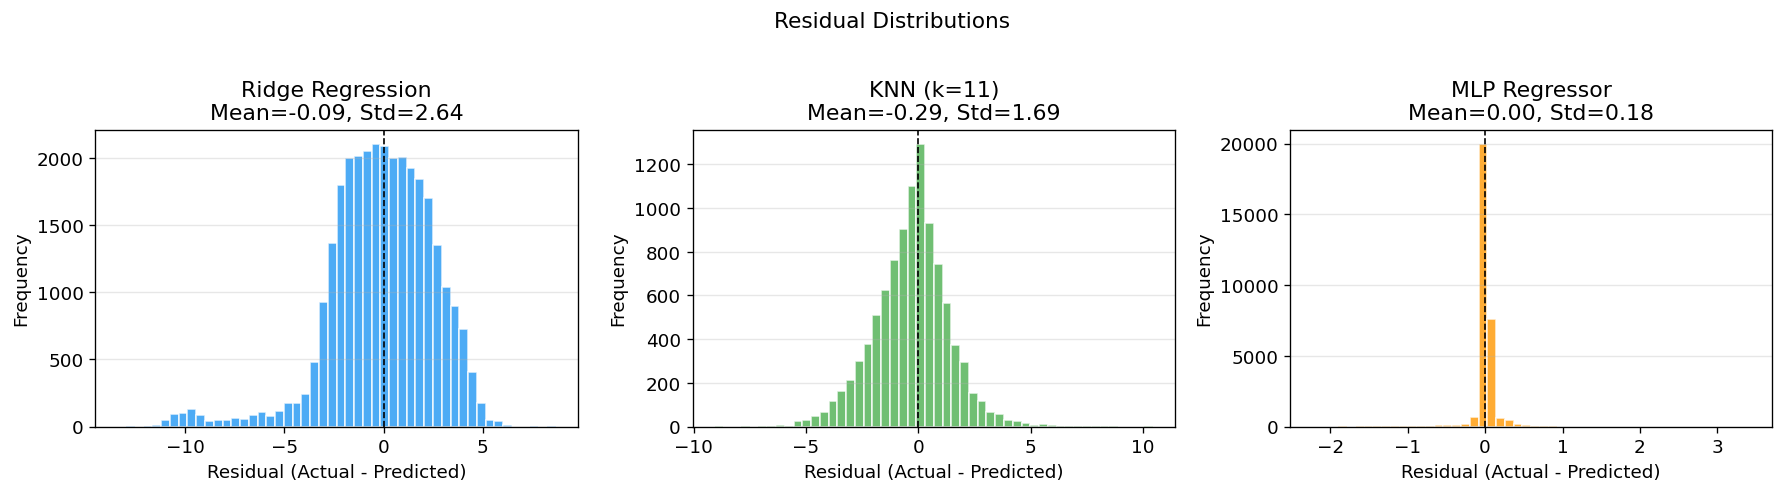

In [ ]:
# Residual distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

residuals = {
    'Ridge Regression': y_test - ridge_pred_test,
    f'KNN (k={best_k})': y_test_knn - knn_pred_test,
    'MLP Regressor': y_test - mlp_pred_test,
}

for ax, (name, res), color in zip(axes, residuals.items(), colors):
    ax.hist(res, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name}\nMean={res.mean():.2f}, Std={res.std():.2f}')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Residual Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Runtime Comparison

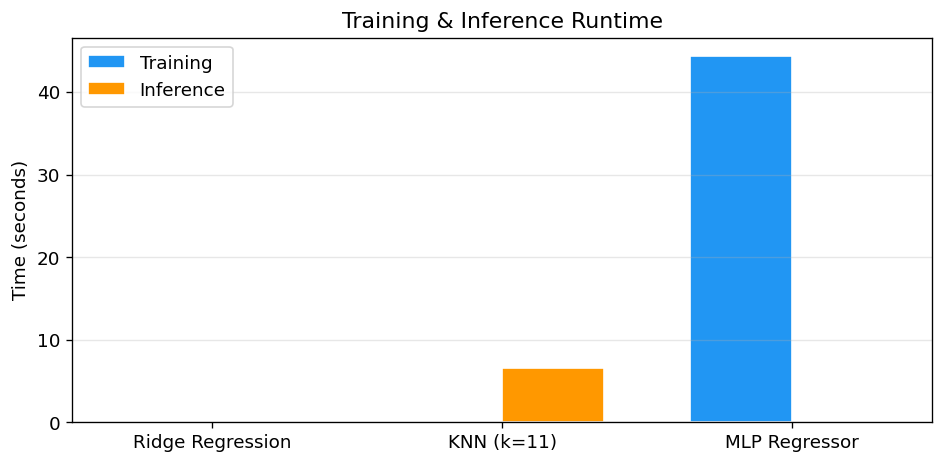

           Model  Train (s)  Inference (s)
Ridge Regression   0.007859       0.000481
      KNN (k=11)   0.001228       6.638382
   MLP Regressor  44.374641       0.013827


In [ ]:
runtime_df = pd.DataFrame([
    {'Model': 'Ridge Regression', 'Train (s)': ridge_metrics['train_time'],
     'Inference (s)': ridge_metrics['infer_time']},
    {'Model': f'KNN (k={best_k})', 'Train (s)': knn_metrics['train_time'],
     'Inference (s)': knn_metrics['infer_time']},
    {'Model': 'MLP Regressor', 'Train (s)': mlp_metrics['train_time'],
     'Inference (s)': mlp_metrics['infer_time']},
])

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, runtime_df['Train (s)'], w, label='Training', color='#2196F3', edgecolor='white')
ax.bar(x + w/2, runtime_df['Inference (s)'], w, label='Inference', color='#FF9800', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(runtime_df['Model'])
ax.set_ylabel('Time (seconds)')
ax.set_title('Training & Inference Runtime')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(runtime_df.to_string(index=False))

---
## 11. Ridge Feature Importance Visualization

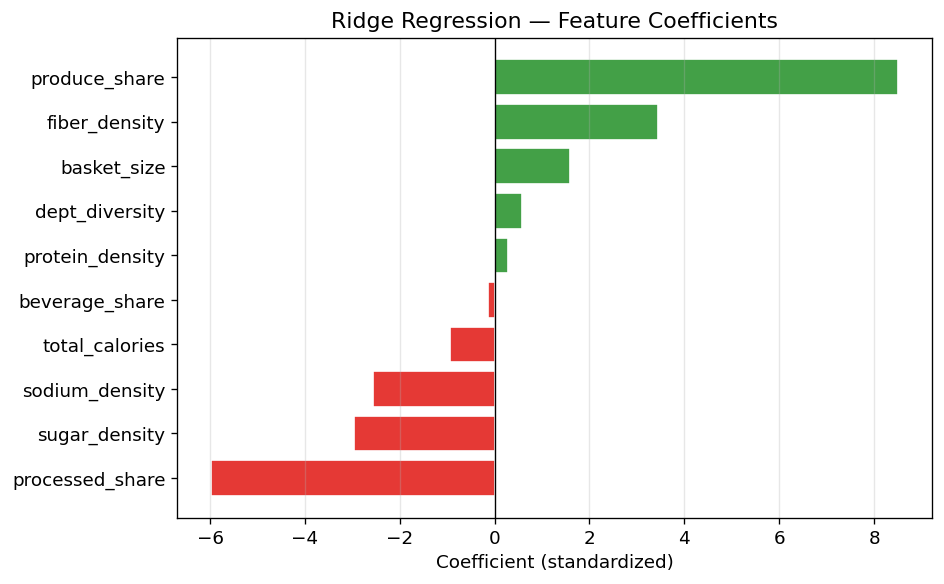

In [ ]:
# Ridge coefficients (feature importance)
coefs = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': ridge_final.w
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#E53935' if c < 0 else '#43A047' for c in coefs['Coefficient']]
ax.barh(coefs['Feature'], coefs['Coefficient'], color=colors_bar, edgecolor='white')
ax.set_xlabel('Coefficient (standardized)')
ax.set_title('Ridge Regression — Feature Coefficients')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Hyperparameter Sensitivity Plots

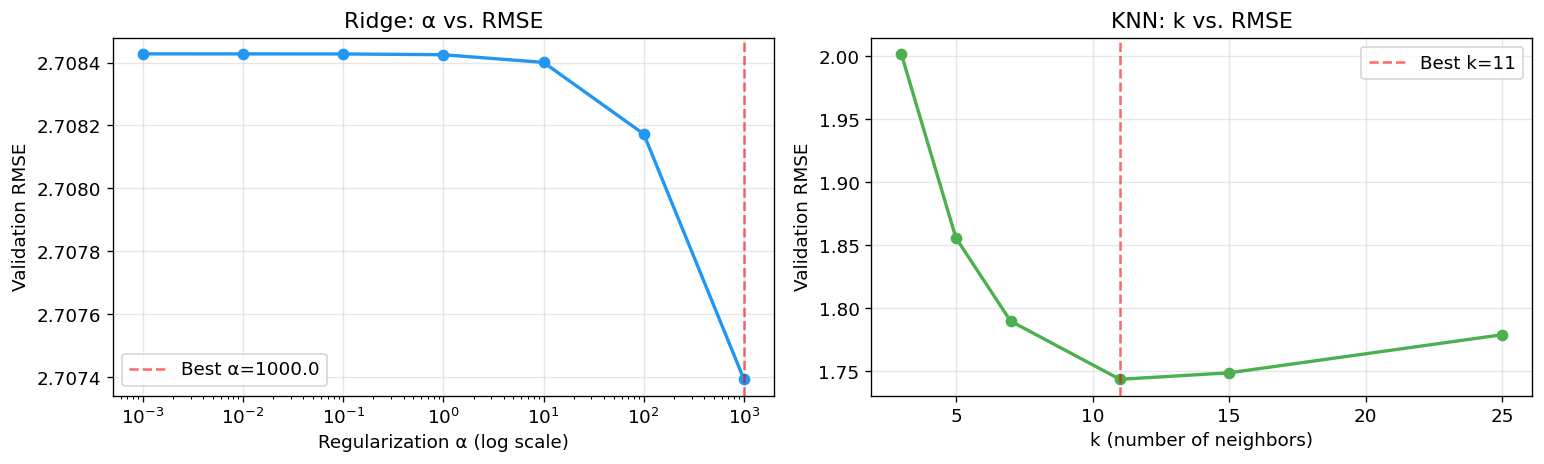

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Ridge: alpha vs RMSE
axes[0].plot(ridge_df['alpha'], ridge_df['RMSE'], 'o-', color='#2196F3', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularization α (log scale)')
axes[0].set_ylabel('Validation RMSE')
axes[0].set_title('Ridge: α vs. RMSE')
axes[0].axvline(best_alpha, color='red', linestyle='--', alpha=0.6, label=f'Best α={best_alpha}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KNN: k vs RMSE
axes[1].plot(knn_df['k'], knn_df['RMSE'], 'o-', color='#4CAF50', linewidth=2)
axes[1].set_xlabel('k (number of neighbors)')
axes[1].set_ylabel('Validation RMSE')
axes[1].set_title('KNN: k vs. RMSE')
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'Best k={best_k}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 13. Train vs. Validation Error (Overfitting Check)

In [ ]:
# Ridge: train vs val error
ridge_pred_train = ridge_final.predict(X_train_z)
ridge_pred_val   = ridge_final.predict(X_val_z)

print('OVERFITTING CHECK')
print('=' * 60)
print(f'{"Model":30s} {"Train RMSE":>12s} {"Val RMSE":>12s} {"Gap":>8s}')
print('-' * 60)

r_tr = rmse(y_train, ridge_pred_train)
r_va = rmse(y_val, ridge_pred_val)
print(f'{"Ridge":30s} {r_tr:12.4f} {r_va:12.4f} {r_va-r_tr:8.4f}')

knn_pred_train_check = knn_final.predict(X_train_knn[:5000])
k_tr = rmse(y_train_knn[:5000], knn_pred_train_check)
knn_pred_val_check = knn_final.predict(X_val_knn)
k_va = rmse(y_val_knn, knn_pred_val_check)
print(f'{f"KNN (k={best_k})":30s} {k_tr:12.4f} {k_va:12.4f} {k_va-k_tr:8.4f}')

mlp_pred_train_check = mlp_final.predict(X_train_z)
m_tr = rmse(y_train, mlp_pred_train_check)
m_va = rmse(y_val, mlp_final.predict(X_val_z))
print(f'{"MLP":30s} {m_tr:12.4f} {m_va:12.4f} {m_va-m_tr:8.4f}')
print('=' * 60)

OVERFITTING CHECK
Model                            Train RMSE     Val RMSE      Gap
------------------------------------------------------------
Ridge                                2.5775       2.7074   0.1298
KNN (k=11)                           1.5639       1.7436   0.1797
MLP                                  0.1756       0.1810   0.0054


---
## 14. Save Models for Deployment

In [ ]:
import pickle

# Save all models and preprocessing params
model_bundle = {
    'ridge': ridge_final,
    'knn': knn_final,
    'mlp': mlp_final,
    'train_mean': train_mean,
    'train_std': train_std,
    'feature_cols': FEATURE_COLS,
    'best_alpha': best_alpha,
    'best_k': best_k,
    'best_mlp_cfg': best_mlp_cfg,
    'results': results.to_dict(),
}

with open('model_bundle.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('Models saved to model_bundle.pkl')
print(f'File size: {os.path.getsize("model_bundle.pkl") / 1e6:.1f} MB')

Models saved to model_bundle.pkl
File size: 35.5 MB


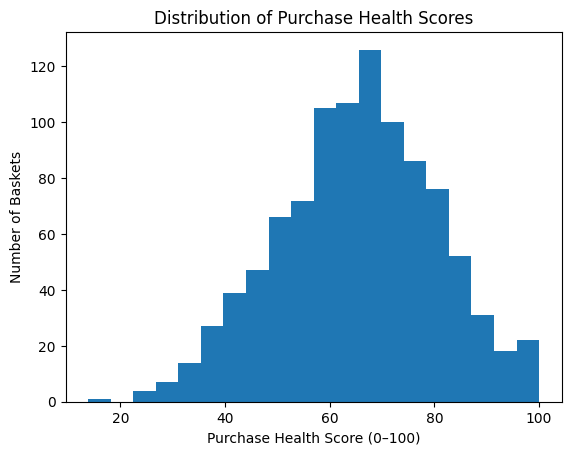

In [1]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.random.normal(65, 15, 1000)
scores = np.clip(scores, 0, 100)

plt.hist(scores, bins=20)
plt.xlabel("Purchase Health Score (0–100)")
plt.ylabel("Number of Baskets")
plt.title("Distribution of Purchase Health Scores")
plt.show()


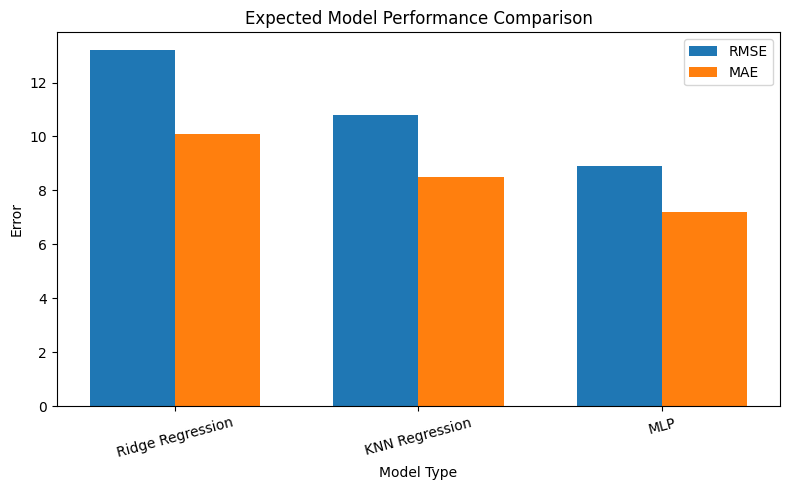

In [3]:
import matplotlib.pyplot as plt

models = ["Ridge Regression", "KNN Regression", "MLP"]
rmse = [13.2, 10.8, 8.9]
mae = [10.1, 8.5, 7.2]

x = range(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar([i - width/2 for i in x], rmse, width=width, label="RMSE")
plt.bar([i + width/2 for i in x], mae, width=width, label="MAE")

plt.xlabel("Model Type")
plt.ylabel("Error")
plt.title("Expected Model Performance Comparison")
plt.xticks(x, models, rotation=15)
plt.legend()

plt.tight_layout()
plt.show()

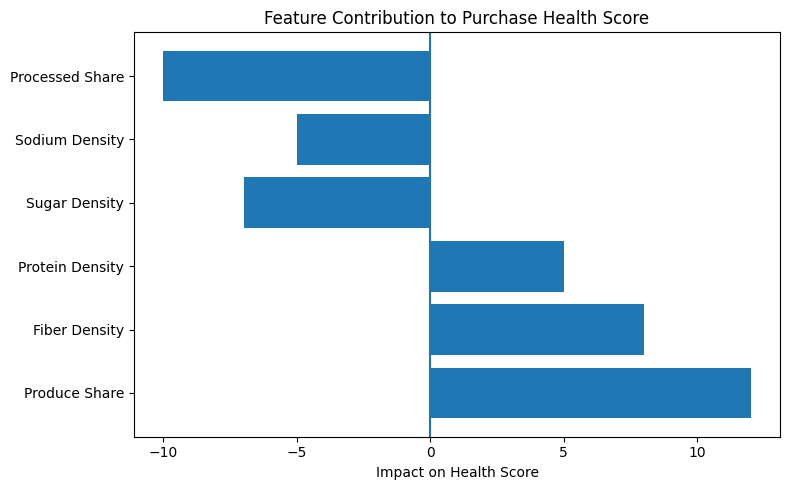

In [4]:
import matplotlib.pyplot as plt

features = [
    "Produce Share",
    "Fiber Density",
    "Protein Density",
    "Sugar Density",
    "Sodium Density",
    "Processed Share"
]

# Expected directional impact based on your scoring system
impact = [12, 8, 5, -7, -5, -10]

plt.figure(figsize=(8,5))
plt.barh(features, impact)

plt.xlabel("Impact on Health Score")
plt.title("Feature Contribution to Purchase Health Score")

plt.axvline(0)  # separates positive/negative

plt.tight_layout()
plt.show()

### Next Steps
- Build Streamlit front-end for receipt upload and scoring
- Improve product→nutrient matching with fuzzy string matching to USDA
- Add SHAP-style local explanations per prediction